# Sapphire Defect Detection with Grad-CAM
Classification + Defect Localization

> **Training policy:** run training only in this `.ipynb` notebook. Do not use a standalone Python training script.

## 1. Setup

In [1]:
import json
import os
import sys
import time
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from pathlib import Path

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')

I0000 00:00:1791638410.104784  348565 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791638410.105139  348565 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791638410.149614  348565 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1791638411.428822  348565 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791638411.429134  348565 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0
GPU: False


E0000 00:00:1791638412.823473  348565 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Configuration

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS_HEAD = 20
EPOCHS_FINETUNE = 20

PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / '.git').exists()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError('Open this notebook from inside the project directory.')

MODULE_DIR = PROJECT_ROOT / 'ml' / 'defect-detection'
if not MODULE_DIR.is_dir():
    MODULE_DIR = PROJECT_ROOT

sys.path.insert(0, str(PROJECT_ROOT / 'backend'))
from reusable_components.image_preprocessing import preprocess_rgb_array

# Three-class defect data available in this repository.
DATA_DIR = MODULE_DIR / 'datasets'
MODEL_DIR = MODULE_DIR / 'keras'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
SAPPHIRE_TYPES = ['blue-sapphire', 'yellow-sapphire']
TRAIN_DIRS = [DATA_DIR / s / 'train' for s in SAPPHIRE_TYPES]
VAL_DIRS = [DATA_DIR / s / 'val' for s in SAPPHIRE_TYPES]
for dataset_dir in TRAIN_DIRS:
    if not dataset_dir.is_dir():
        raise FileNotFoundError(f'Dataset directory not found: {dataset_dir}')
CLASS_NAMES = sorted(entry.name for entry in TRAIN_DIRS[0].iterdir() if entry.is_dir())
NUM_CLASSES = len(CLASS_NAMES)

DEFECT_INFO = {
    'crack': {'name': 'Crack', 'severity': 'HIGH', 'desc': 'Visible fracture in crystal structure', 'loc': 'Surface or internal fracture'},
    'inclusion': {'name': 'Inclusion', 'severity': 'MEDIUM', 'desc': 'Internal inclusion', 'loc': 'Internal body of stone'},
    'normal': {'name': 'Normal', 'severity': 'NONE', 'desc': 'No defects found', 'loc': 'N/A'},
}

print(f'Classes: {CLASS_NAMES}')
print(f'Sapphire types: {SAPPHIRE_TYPES}')
print(f'Project root: {PROJECT_ROOT}')


Classes: ['crack', 'inclusion', 'normal']
Sapphire types: ['blue-sapphire', 'yellow-sapphire']
Project root: /home/anuk/Downloads/GemVision/GemVision


## 3. Data Exploration

In [3]:
for sapphire_type in SAPPHIRE_TYPES:
    for split in ['train', 'val']:
        d = DATA_DIR / sapphire_type / split
        print(f'\n{sapphire_type}/{split}:')
        for cls in CLASS_NAMES:
            n = len(list((d / cls).glob('*.jpg'))) + len(list((d / cls).glob('*.png')))
            print(f'  {cls}: {n}')

print('\n--- Combined ---')
for split in ['train', 'val']:
    print(f'\n{split}:')
    for cls in CLASS_NAMES:
        n = sum(len(list((d / cls).glob('*.jpg'))) + len(list((d / cls).glob('*.png'))) for d in [DATA_DIR / s / split for s in SAPPHIRE_TYPES])
        print(f'  {cls}: {n}')


blue-sapphire/train:
  crack: 5
  inclusion: 42
  normal: 30

blue-sapphire/val:
  crack: 0
  inclusion: 0
  normal: 0

yellow-sapphire/train:
  crack: 1
  inclusion: 1
  normal: 25

yellow-sapphire/val:
  crack: 0
  inclusion: 0
  normal: 0

--- Combined ---

train:
  crack: 6
  inclusion: 43
  normal: 55

val:
  crack: 0
  inclusion: 0
  normal: 0


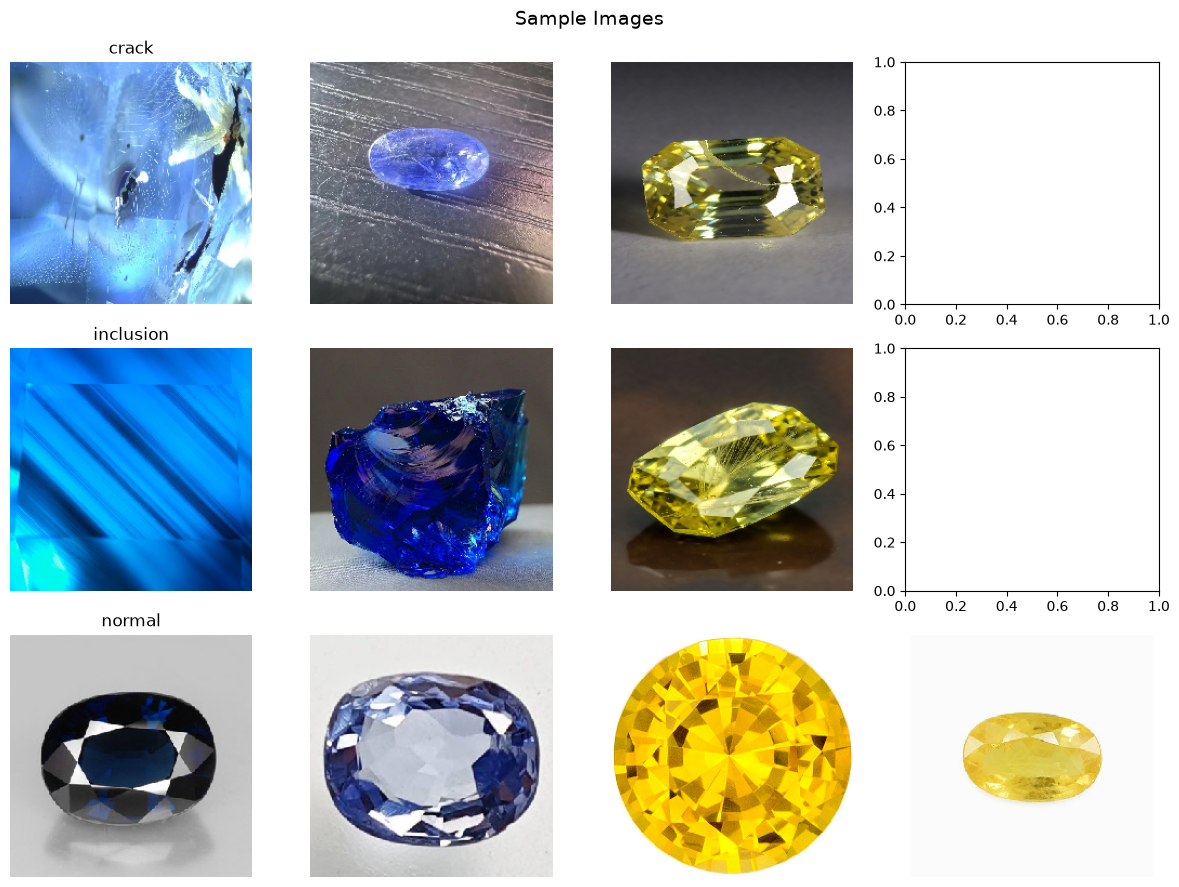

In [4]:
fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(12, 3 * NUM_CLASSES))
for i, cls in enumerate(CLASS_NAMES):
    imgs = []
    for train_dir in TRAIN_DIRS:
        imgs.extend(list((train_dir / cls).glob('*.jpg'))[:2])
    imgs = imgs[:4]
    for j, p in enumerate(imgs):
        axes[i, j].imshow(tf.keras.utils.load_img(p, target_size=IMG_SIZE))
        axes[i, j].set_title(cls if j == 0 else '')
        axes[i, j].axis('off')
plt.suptitle('Sample Images', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Data Loading

In [5]:
def _list_split(base_dir):
    class_names = sorted(entry.name for entry in base_dir.iterdir() if entry.is_dir())
    files, labels = [], []
    for index, cls in enumerate(class_names):
        images = sorted((base_dir / cls).glob('*.jpg')) + sorted((base_dir / cls).glob('*.png'))
        files.extend(images)
        labels.extend([index] * len(images))
    return class_names, files, labels


def _decode_image(path, label):
    image = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image.set_shape(IMG_SIZE + (3,))
    return image, tf.one_hot(label, NUM_CLASSES)


def _file_dataset(files, labels, shuffle):
    dataset = tf.data.Dataset.from_tensor_slices(
        ([str(path) for path in files], np.asarray(labels, dtype=np.int32))
    )
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(files), seed=42)
    return dataset.map(_decode_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE)


train_datasets = []
val_datasets = []
for train_dir, val_dir in zip(TRAIN_DIRS, VAL_DIRS):
    if not train_dir.is_dir():
        continue
    dir_class_names, files, labels = _list_split(train_dir)
    if not files:
        continue
    if set(dir_class_names) != set(CLASS_NAMES):
        raise ValueError(f'Class folders do not match in {train_dir}')

    if val_dir.is_dir():
        train_datasets.append(tf.keras.utils.image_dataset_from_directory(
            train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
            label_mode='categorical', shuffle=True, seed=42
        ))
        val_datasets.append(tf.keras.utils.image_dataset_from_directory(
            val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
            label_mode='categorical', shuffle=False
        ))
        continue

    # No val split on disk: build a stratified 20% hold-out so every class is
    # represented (image_dataset_from_directory does not shuffle before splitting).
    rng = np.random.default_rng(42)
    train_files, train_labels, val_files, val_labels = [], [], [], []
    for index in range(len(dir_class_names)):
        class_files = [path for path, label in zip(files, labels) if label == index]
        rng.shuffle(class_files)
        n_val = max(1, int(round(0.2 * len(class_files)))) if len(class_files) > 1 else 0
        val_files.extend(class_files[:n_val])
        val_labels.extend([index] * n_val)
        train_files.extend(class_files[n_val:])
        train_labels.extend([index] * (len(class_files) - n_val))

    train_datasets.append(_file_dataset(train_files, train_labels, shuffle=True))
    val_datasets.append(_file_dataset(val_files, val_labels, shuffle=False))

if not train_datasets:
    raise RuntimeError('No training images found under the dataset directories.')

train_ds = train_datasets[0]
for ds in train_datasets[1:]:
    train_ds = train_ds.concatenate(ds)

val_ds = val_datasets[0]
for ds in val_datasets[1:]:
    val_ds = val_ds.concatenate(ds)

train_ds = train_ds.shuffle(buffer_size=1000, seed=42)

print(f'Combined training batches: {len(train_ds)}')
print(f'Combined validation batches: {len(val_ds)}')


Combined training batches: 6
Combined validation batches: 2


In [6]:
try:
    from sklearn.utils.class_weight import compute_class_weight
    labels = [int(tf.argmax(y)) for _, y in train_ds.unbatch()]
    labels = np.array(labels)
    unique = np.unique(labels)
    weights = compute_class_weight('balanced', classes=unique, y=labels)
    class_weight = {int(c): float(w) for c, w in zip(unique, weights)}
except Exception:
    class_weight = {index: 1.0 for index in range(NUM_CLASSES)}

print('Class weights:', {CLASS_NAMES[i]: round(w, 2) for i, w in class_weight.items()})

AUTOTUNE = tf.data.AUTOTUNE

def preprocess_for_model(image):
    prepared = tf.numpy_function(
        lambda array: preprocess_rgb_array(array, IMG_SIZE)[0], [image], tf.float32
    )
    prepared.set_shape(IMG_SIZE + (3,))
    return prepared

def preprocess_dataset(images, labels):
    prepared_images = tf.map_fn(
        preprocess_for_model, images,
        fn_output_signature=tf.TensorSpec(shape=IMG_SIZE + (3,), dtype=tf.float32)
    )
    return prepared_images, labels

# Match the app: noise reduction followed by an HSV gemstone crop.
train_ds = train_ds.map(preprocess_dataset, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(preprocess_dataset, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

Class weights: {'crack': 5.6, 'inclusion': 0.8, 'normal': 0.64}


## 5. Augmentation

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15),
    layers.RandomTranslation(0.08, 0.08),
    layers.GaussianNoise(0.05),
], name='augmentation')

## 6. Model Architecture

In [8]:
base_model = tf.keras.applications.EfficientNetV2S(
    input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = models.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,694,115 (78.94 MB)

 Trainable params: 361,987 (1.38 MB)

 Non-trainable params: 20,332,128 (77.56 MB)

## 7. Training - Stage 1 (Head Only)

In [9]:
TRAINING_START = time.perf_counter()

In [10]:
lr_schedule_head = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, decay_steps=EPOCHS_HEAD * len(train_ds), alpha=1e-6
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule_head),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(str(MODEL_DIR / 'sapphire_model.keras'), save_best_only=True, monitor='val_accuracy'),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
]
history_head = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
    class_weight=class_weight, callbacks=callbacks
)

Epoch 1/20


/home/anuk/Downloads/gem/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1/6 ━━━━━━━━━━━━━━━━━━━━ 4:56 59s/step - accuracy: 0.4286 - loss: 2.7773

2/6 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.5500 - loss: 2.0799   

3/6 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.5278 - loss: 1.7112

...

3/6 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step - accuracy: 0.9167 - loss: 0.5367

4/6 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step - accuracy: 0.8654 - loss: 0.5582

5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.8824 - loss: 0.5342

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 690ms/step - accuracy: 0.8929 - loss: 0.4954

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 875ms/step - accuracy: 0.8929 - loss: 0.4954 - val_accuracy: 0.8000 - val_loss: 0.6571


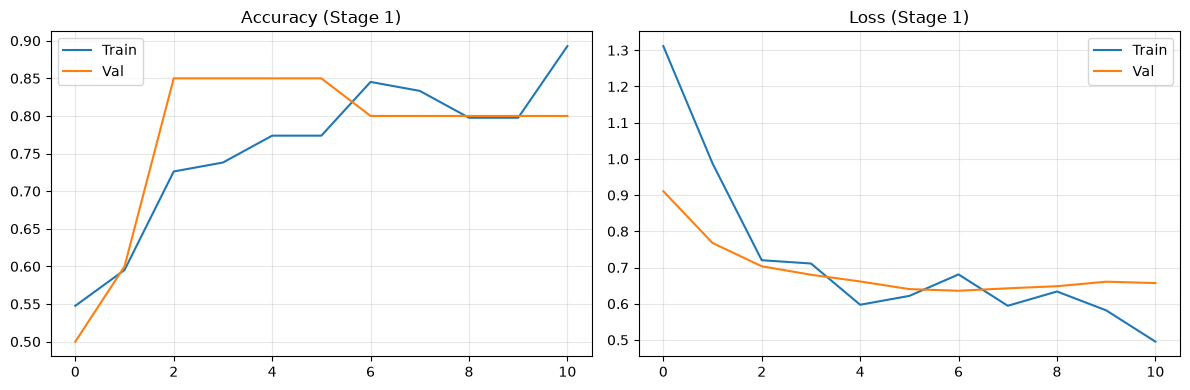

In [11]:
def plot_history(history, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Val')
    ax1.set_title(f'Accuracy {title}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Val')
    ax2.set_title(f'Loss {title}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history(history_head, '(Stage 1)')

## 8. Training - Stage 2 (Fine-tune)

Epoch 1/20


1/6 ━━━━━━━━━━━━━━━━━━━━ 1:09 14s/step - accuracy: 0.7857 - loss: 0.7554

2/6 ━━━━━━━━━━━━━━━━━━━━ 1s 435ms/step - accuracy: 0.6500 - loss: 0.7129

3/6 ━━━━━━━━━━━━━━━━━━━━ 2s 772ms/step - accuracy: 0.6944 - loss: 0.6394

4/6 ━━━━━━━━━━━━━━━━━━━━ 1s 855ms/step - accuracy: 0.7115 - loss: 0.8334

...

3/6 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step - accuracy: 0.8056 - loss: 0.6963

4/6 ━━━━━━━━━━━━━━━━━━━━ 1s 636ms/step - accuracy: 0.7308 - loss: 0.6934

5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - accuracy: 0.7206 - loss: 0.7164

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - accuracy: 0.7381 - loss: 0.6731

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 896ms/step - accuracy: 0.7381 - loss: 0.6731 - val_accuracy: 0.7000 - val_loss: 0.7468


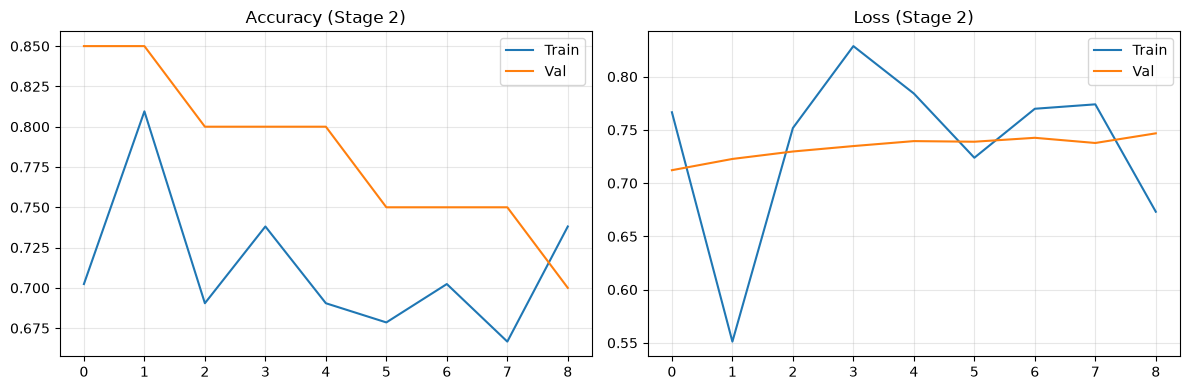

In [12]:
base_model.trainable = True
for layer in base_model.layers[:-15]:
    layer.trainable = False

lr_schedule_ft = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5, decay_steps=EPOCHS_FINETUNE * len(train_ds), alpha=1e-7
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule_ft),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
history_ft = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_FINETUNE,
    class_weight=class_weight, callbacks=callbacks
)
plot_history(history_ft, '(Stage 2)')

## 9. Evaluation

In [13]:
loss, accuracy = model.evaluate(val_ds)
print(f'Validation Accuracy: {accuracy*100:.1f}%')

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.8000 - loss: 0.7148

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.8500 - loss: 0.7122

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - accuracy: 0.8500 - loss: 0.7122


Validation Accuracy: 85.0%


              precision    recall  f1-score   support

       crack       0.00      0.00      0.00         1
   inclusion       1.00      0.75      0.86         8
      normal       0.92      1.00      0.96        11

    accuracy                           0.85        20
   macro avg       0.64      0.58      0.60        20
weighted avg       0.90      0.85      0.87        20



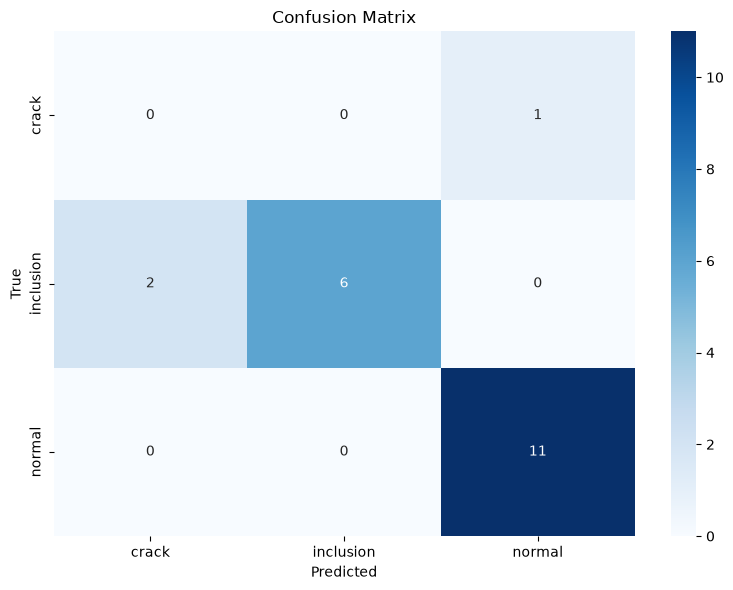

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(tf.argmax(labels, axis=1).numpy())
    y_pred.extend(tf.argmax(preds, axis=1).numpy())

print(classification_report(np.array(y_true), np.array(y_pred), target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 10. MobileNetV2 Model
Smaller backbone (3.4M params) for comparison

In [15]:
base_model_mn = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet'
)
base_model_mn.trainable = False

inputs_mn = tf.keras.Input(shape=IMG_SIZE + (3,))
x_mn = data_augmentation(inputs_mn)
x_mn = tf.keras.applications.mobilenet_v2.preprocess_input(x_mn)
x_mn = base_model_mn(x_mn, training=False)
x_mn = layers.GlobalAveragePooling2D()(x_mn)
x_mn = layers.Dense(256)(x_mn)
x_mn = layers.BatchNormalization()(x_mn)
x_mn = layers.Activation('relu')(x_mn)
x_mn = layers.Dropout(0.5)(x_mn)
x_mn = layers.Dense(128)(x_mn)
x_mn = layers.BatchNormalization()(x_mn)
x_mn = layers.Activation('relu')(x_mn)
x_mn = layers.Dropout(0.3)(x_mn)
outputs_mn = layers.Dense(NUM_CLASSES, activation='softmax')(x_mn)
model_mn = models.Model(inputs_mn, outputs_mn)
model_mn.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,739 (10.00 MB)

 Trainable params: 361,987 (1.38 MB)

 Non-trainable params: 2,258,752 (8.62 MB)

### 10.1 MobileNetV2 - Stage 1 (Head Only)

In [16]:
lr_schedule_head_mn = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, decay_steps=EPOCHS_HEAD * len(train_ds), alpha=1e-6
)

model_mn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule_head_mn),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
callbacks_mn = [
    tf.keras.callbacks.ModelCheckpoint(str(MODEL_DIR / 'sapphire_model_mobilenet.keras'), save_best_only=True, monitor='val_accuracy'),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
]
history_head_mn = model_mn.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
    class_weight=class_weight, callbacks=callbacks_mn
)

Epoch 1/20


/home/anuk/Downloads/gem/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1/6 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.5000 - loss: 1.8415

2/6 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.3500 - loss: 1.5702

3/6 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.3333 - loss: 1.6047

...

3/6 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8056 - loss: 0.6565

4/6 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.8269 - loss: 0.6632

5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.8529 - loss: 0.6133

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.8690 - loss: 0.5651

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 239ms/step - accuracy: 0.8690 - loss: 0.5651 - val_accuracy: 0.8000 - val_loss: 0.7600


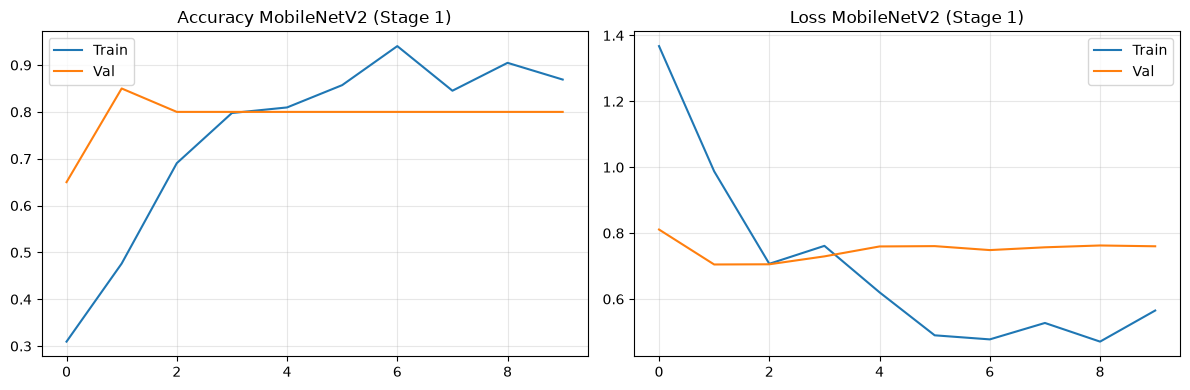

In [17]:
plot_history(history_head_mn, 'MobileNetV2 (Stage 1)')

### 10.2 MobileNetV2 - Stage 2 (Fine-tune)

Epoch 1/20


1/6 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.5714 - loss: 0.9487

2/6 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4000 - loss: 1.0560

3/6 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.4444 - loss: 1.0793

4/6 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.4808 - loss: 1.0044

...

3/6 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.5833 - loss: 0.7557

4/6 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.5769 - loss: 0.7699

5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.5441 - loss: 0.8616

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.5595 - loss: 0.8216

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 479ms/step - accuracy: 0.5595 - loss: 0.8216 - val_accuracy: 0.8000 - val_loss: 0.6635


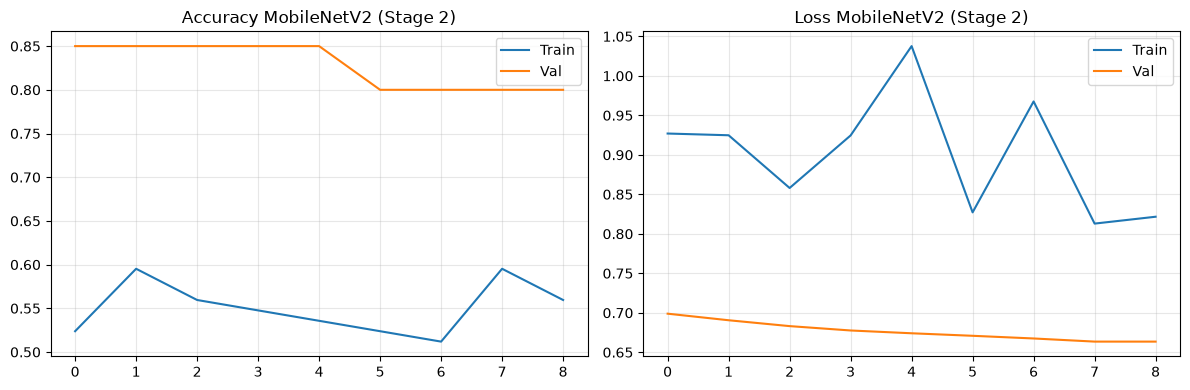

In [18]:
base_model_mn.trainable = True
for layer in base_model_mn.layers[:-15]:
    layer.trainable = False

lr_schedule_ft_mn = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5, decay_steps=EPOCHS_FINETUNE * len(train_ds), alpha=1e-7
)

model_mn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule_ft_mn),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
history_ft_mn = model_mn.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_FINETUNE,
    class_weight=class_weight, callbacks=callbacks_mn
)
plot_history(history_ft_mn, 'MobileNetV2 (Stage 2)')

In [19]:
TRAINING_SECONDS = time.perf_counter() - TRAINING_START
hours, remainder = divmod(TRAINING_SECONDS, 3600)
minutes, seconds = divmod(remainder, 60)
print(f'Total training time: {int(hours)}h {int(minutes)}m {seconds:.1f}s')

Total training time: 0h 4m 18.5s


In [20]:
loss_mn, accuracy_mn = model_mn.evaluate(val_ds)
print(f'MobileNetV2 Validation Accuracy: {accuracy_mn*100:.1f}%')

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9333 - loss: 0.5781

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8500 - loss: 0.6989 

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8500 - loss: 0.6989


MobileNetV2 Validation Accuracy: 85.0%


              precision    recall  f1-score   support

       crack       0.00      0.00      0.00         1
   inclusion       0.73      1.00      0.84         8
      normal       1.00      0.82      0.90        11

    accuracy                           0.85        20
   macro avg       0.58      0.61      0.58        20
weighted avg       0.84      0.85      0.83        20



/home/anuk/Downloads/gem/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/anuk/Downloads/gem/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/anuk/Downloads/gem/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

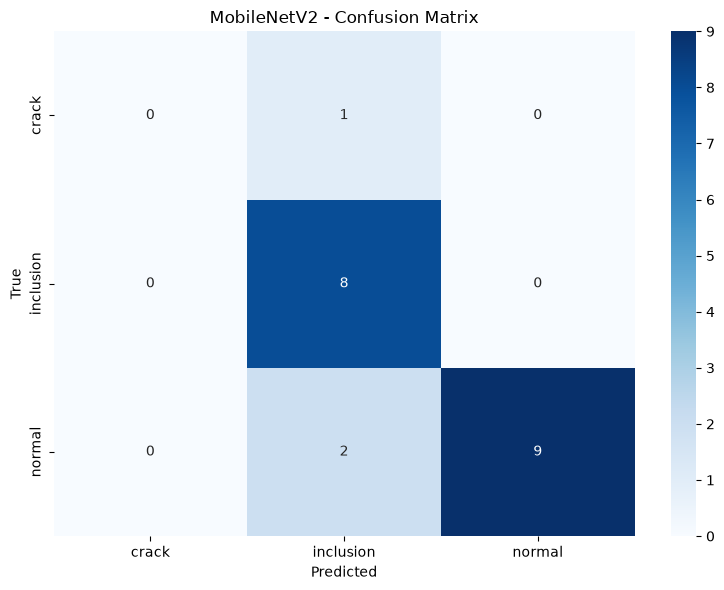

In [21]:
y_true_mn, y_pred_mn = [], []
for images, labels in val_ds:
    preds = model_mn.predict(images, verbose=0)
    y_true_mn.extend(tf.argmax(labels, axis=1).numpy())
    y_pred_mn.extend(tf.argmax(preds, axis=1).numpy())

print(classification_report(np.array(y_true_mn), np.array(y_pred_mn), target_names=CLASS_NAMES))

cm_mn = confusion_matrix(y_true_mn, y_pred_mn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mn, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('MobileNetV2 - Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 11. Model Comparison

In [22]:
print('='*60)
print('MODEL COMPARISON')
print('='*60)

en_params = sum(int(np.prod(p.shape)) for p in model.trainable_weights)
mn_params = sum(int(np.prod(p.shape)) for p in model_mn.trainable_weights)

print(f'\n{"Metric":<25} {"EfficientNetV2-S":<20} {"MobileNetV2":<20}')
print('-'*60)
print(f'{"Val Accuracy":<25} {accuracy*100:.1f}%{"":<14} {accuracy_mn*100:.1f}%')
print(f'{"Trainable Params":<25} {en_params:>10,}{"":<10} {mn_params:>10,}')
print(f'{"Total Model Size (MB)":<25} {79:<20} {14:<20}')

from sklearn.metrics import f1_score
f1_en = f1_score(y_true, y_pred, average='weighted')
f1_mn = f1_score(y_true_mn, y_pred_mn, average='weighted')
print(f'{"Weighted F1":<25} {f1_en:.3f}{"":<17} {f1_mn:.3f}')

print('\n--- Per-class F1 ---')
f1_en_per = f1_score(y_true, y_pred, average=None)
f1_mn_per = f1_score(y_true_mn, y_pred_mn, average=None)
for i, cls in enumerate(CLASS_NAMES):
    print(f'{cls:<25} {f1_en_per[i]:.3f}{"":<17} {f1_mn_per[i]:.3f}')

best = 'EfficientNetV2-S' if f1_en >= f1_mn else 'MobileNetV2'
print(f'\nBest model: {best}')

MODEL COMPARISON

Metric                    EfficientNetV2-S     MobileNetV2         
------------------------------------------------------------
Val Accuracy              85.0%               85.0%
Trainable Params           1,301,059            1,401,987
Total Model Size (MB)     79                   14                  
Weighted F1               0.869                  0.832

--- Per-class F1 ---
crack                     0.000                  0.000
inclusion                 0.857                  0.842
normal                    0.957                  0.900

Best model: EfficientNetV2-S


## 12. Grad-CAM: Defect Localization
Red areas = where the model looks = likely defect location

In [23]:
def detect_gem_mask(img_bgr):
    """Detect sapphire gem region using HSV color filtering (blue + yellow)."""
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    
    # Blue sapphire
    lower_blue = np.array([95, 30, 30])
    upper_blue = np.array([135, 255, 255])
    mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)
    lower_dark = np.array([90, 20, 15])
    upper_dark = np.array([140, 255, 200])
    mask_dark = cv2.inRange(hsv, lower_dark, upper_dark)
    
    # Yellow sapphire
    lower_yellow = np.array([15, 30, 30])
    upper_yellow = np.array([40, 255, 255])
    mask_yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)
    
    mask = cv2.bitwise_or(cv2.bitwise_or(mask_blue, mask_dark), mask_yellow)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels <= 1:
        h, w = mask.shape
        mask = np.zeros_like(mask)
        margin_h, margin_w = int(h * 0.2), int(w * 0.2)
        mask[margin_h:h - margin_h, margin_w:w - margin_w] = 255
        return mask
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    mask = np.where(labels == largest_label, 255, 0).astype(np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=2)
    return mask

def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name, pred_index=None, preprocess_fn=None):
    """Grad-CAM: rebuild forward pass from base_model.input to avoid graph disconnection."""
    conv_layer = base_model.get_layer(last_conv_layer_name)
    
    if preprocess_fn is None:
        preprocess_fn = tf.keras.applications.efficientnet_v2.preprocess_input
    preprocessed = preprocess_fn(img_array.copy())
    
    # Rebuild classifier path from base_model.output (bypasses augmentation layers)
    classifier_layers = []
    capture = False
    for layer in model.layers:
        if layer is base_model or getattr(layer, 'name', '') == base_model.name:
            capture = True
            continue
        if capture:
            classifier_layers.append(layer)
    
    x = base_model.output
    for layer in classifier_layers:
        x = layer(x, training=False)
    
    grad_model = tf.keras.Model(inputs=base_model.input, outputs=[conv_layer.output, x])
    
    with tf.GradientTape() as tape:
        conv_out, predictions = grad_model(preprocessed, training=False)
        if pred_index is None:
            pred_index = int(tf.argmax(predictions[0]))
        loss = predictions[0, pred_index]
    
    grads = tape.gradient(loss, conv_out)
    weights = tf.reduce_mean(grads[0], axis=(0, 1))
    cam = tf.einsum('hwc,c->hw', conv_out[0], weights)
    cam = tf.maximum(cam, 0)
    cam = cam / (tf.math.reduce_max(cam) + 1e-8)
    return cam.numpy()

In [24]:
def display_gradcam(image_path, model, base_model, class_names, defect_info, preprocess_fn=None):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array_exp = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array_exp, verbose=0)[0]
    top_idx = int(np.argmax(preds))
    top_class = class_names[top_idx]

    last_conv = None
    for layer in reversed(base_model.layers):
        if hasattr(layer, 'output_shape') and len(layer.output_shape) == 4:
            last_conv = layer.name
            break
    if last_conv is None:
        last_conv = base_model.layers[-1].name

    heatmap = make_gradcam_heatmap(img_array_exp, model, base_model, last_conv, top_idx, preprocess_fn=preprocess_fn)

    heatmap = tf.image.resize(tf.expand_dims(heatmap, axis=-1), IMG_SIZE).numpy()[:, :, 0]

    img_bgr = cv2.cvtColor(img_array.astype(np.uint8), cv2.COLOR_RGB2BGR)
    gem_mask = detect_gem_mask(img_bgr)
    gem_mask_resized = cv2.resize(gem_mask, IMG_SIZE, interpolation=cv2.INTER_LINEAR).astype(np.float32) / 255.0
    gem_mask_binary = (gem_mask_resized > 0.5).astype(np.float32)
    heatmap_masked = heatmap * gem_mask_binary
    gem_coverage = float(gem_mask_binary.mean()) * 100
    print(f'Gem detected: {gem_coverage:.1f}% of image')

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    axes[0, 0].imshow(img)
    axes[0, 0].set_title('Original Image', fontweight='bold')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(heatmap_masked, cmap='jet')
    axes[0, 1].set_title('Grad-CAM Heatmap (Gem Only)', fontweight='bold')
    axes[0, 1].axis('off')

    img_norm = img_array / 255.0
    axes[0, 2].imshow(img_norm)
    axes[0, 2].imshow(heatmap_masked, cmap='jet', alpha=0.4)
    axes[0, 2].set_title('Defect Location (Gem Only)', fontweight='bold')
    axes[0, 2].axis('off')

    colors = ['#e74c3c' if i == top_idx else '#95a5a6' for i in range(len(class_names))]
    bars = axes[1, 0].barh(class_names, preds * 100, color=colors)
    axes[1, 0].set_xlim(0, 100)
    axes[1, 0].set_xlabel('Confidence (%)')
    axes[1, 0].set_title('Classification', fontweight='bold')
    for bar, prob in zip(bars, preds):
        axes[1, 0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{prob*100:.1f}%', va='center')

    axes[1, 1].axis('off')
    info = defect_info.get(top_class, {})
    txt = f"DEFECT ANALYSIS\n{'='*35}\n"
    txt += f"\nDetected: {info.get('name', '?')}"
    txt += f"\nSeverity: {info.get('severity', '?')}"
    txt += f"\n\n{info.get('desc', 'N/A')}"
    txt += f"\n\nLocation: {info.get('loc', 'N/A')}"
    axes[1, 1].text(0.1, 0.9, txt, transform=axes[1, 1].transAxes,
        fontsize=11, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    axes[1, 1].set_title('Defect Details', fontweight='bold')

    axes[1, 2].axis('off')
    defect_coords = np.where(heatmap_masked > 0.5)
    if len(defect_coords[0]) > 0:
        ymin = defect_coords[0].min() / heatmap_masked.shape[0] * 100
        ymax = defect_coords[0].max() / heatmap_masked.shape[0] * 100
        xmin = defect_coords[1].min() / heatmap_masked.shape[1] * 100
        xmax = defect_coords[1].max() / heatmap_masked.shape[1] * 100
        pct = len(defect_coords[0]) / (heatmap_masked.shape[0] * heatmap_masked.shape[1]) * 100
        loc = f"DEFECT LOCATION\n{'='*35}\n"
        loc += f"\nCoverage: {pct:.1f}% of image"
        loc += f"\n\nBounding Box:"
        loc += f"\n  X: {xmin:.0f}% - {xmax:.0f}%"
        loc += f"\n  Y: {ymin:.0f}% - {ymax:.0f}%"
        loc += f"\n\nCenter: ({(xmin+xmax)/2:.0f}%, {(ymin+ymax)/2:.0f}%)"
    else:
        loc = f"DEFECT LOCATION\n{'='*35}\n\nNo defect region detected"
    axes[1, 2].text(0.1, 0.9, loc, transform=axes[1, 2].transAxes,
        fontsize=11, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    axes[1, 2].set_title('Location Analysis', fontweight='bold')

    plt.suptitle(f'Defect Analysis: {Path(image_path).name}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f'Classification: {top_class.upper()} ({preds[top_idx]*100:.1f}%)')
    print(f'Severity: {info.get("severity", "Unknown")}')
    return top_class, preds, heatmap_masked

## 13. Test on Validation Images

In [25]:
print('=== EfficientNetV2-S ===')
for cls in CLASS_NAMES:
    imgs = []
    for val_dir in VAL_DIRS:
        imgs.extend(list((val_dir / cls).glob('*.jpg')))
    imgs = imgs[:1]
    if imgs:
        print(f'\nTrue label: {cls}')
        display_gradcam(str(imgs[0]), model, base_model, CLASS_NAMES, DEFECT_INFO,
                        preprocess_fn=tf.keras.applications.efficientnet_v2.preprocess_input)

print('\n\n=== MobileNetV2 ===')
for cls in CLASS_NAMES:
    imgs = []
    for val_dir in VAL_DIRS:
        imgs.extend(list((val_dir / cls).glob('*.jpg')))
    imgs = imgs[:1]
    if imgs:
        print(f'\nTrue label: {cls}')
        display_gradcam(str(imgs[0]), model_mn, base_model_mn, CLASS_NAMES, DEFECT_INFO,
                        preprocess_fn=tf.keras.applications.mobilenet_v2.preprocess_input)

=== EfficientNetV2-S ===


=== MobileNetV2 ===


## 14. Save Model

In [26]:
model.save(str(MODEL_DIR / 'sapphire_model.keras'))
model_mn.save(str(MODEL_DIR / 'sapphire_model_mobilenet.keras'))
metadata = {
    'class_names': CLASS_NAMES,
    'model_requirement': 'defect_detection',
    'image_size': list(IMG_SIZE),
    'training_source': 'notebooks/defect-detection/sapphire_defect_classifier.ipynb',
    'training_time_seconds': round(TRAINING_SECONDS, 1),
}
(MODEL_DIR / 'model_metadata.json').write_text(json.dumps(metadata, indent=2) + '\n', encoding='utf-8')
print(f'Both models and model_metadata.json saved! (training time {TRAINING_SECONDS:.1f}s)')

Both models and model_metadata.json saved! (training time 258.5s)


## 15. Test Your Own Image
Uncomment and set your image path below:

In [27]:
# display_gradcam('path/to/your_image.jpg', model, base_model, CLASS_NAMES, DEFECT_INFO)